# Experiment on CNN

In [4]:
import kagglehub

path = kagglehub.dataset_download("agrigorev/clothing-dataset-full")

print("Path to dataset files:", path)

c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Utilisateur\.cache\kagglehub\datasets\agrigorev\clothing-dataset-full\versions\1


## Filter out corrupted images

In [5]:
import os

num_skipped = 0
valid_image = []  # Store names of deleted files

for folder_name in ("images_compressed", "images_original"):
    folder_path = os.path.join(path, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)
        else:
            valid_image.append(fname.lstrip("0").removesuffix(".jpg"))

print(f"Deleted {num_skipped} images.")

Deleted 0 images.


## Load the images, remove the corrupted one

In [6]:
import torch
import torchvision.ops as ops
import numpy as np
import pandas as pd
from PIL import Image

def load_image(image_id):
    image_path = f"{path}/images_compressed/{image_id}.jpg"
    image = Image.open(image_path)
    resized_imge = image.resize((224, 224))
    return np.array(resized_imge, )

df = pd.read_csv(path + "/images.csv", na_values=["Not sure"])
df = df.dropna()
df = df[df['image'].isin(valid_image)].reset_index(drop=True)
df['image_data'] = df['image'].apply(load_image)


## Show the first image to see if the loading worked

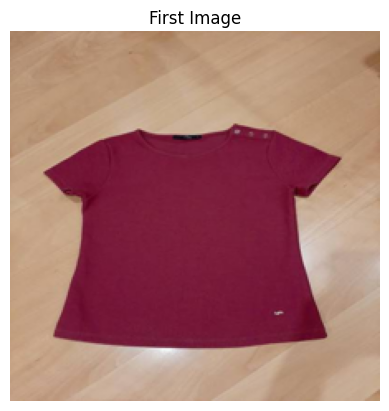

In [7]:
import matplotlib.pyplot as plt

first_image = df['image_data'].iloc[0]

plt.imshow(first_image)
plt.axis('off')
plt.title("First Image")
plt.show()

## Transform label from string to number

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

df

,image,sender_id,label,kids,image_data,label_encoded
0,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False,"[[[170, 133, 104], [169, 132, 103], [167, 130,...",16
1,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False,"[[[183, 151, 121], [178, 147, 115], [180, 149,...",16
2,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False,"[[[207, 151, 90], [206, 150, 89], [207, 151, 9...",12
3,5d3a1404-697f-479f-9090-c1ecd0413d27,138,Shorts,False,"[[[210, 180, 146], [209, 179, 145], [208, 178,...",13
4,b0c03127-9dfb-4573-8934-1958396937bf,138,Shirt,False,"[[[208, 188, 156], [207, 187, 155], [208, 188,...",11
...,...,...,...,...,...,...
4841,dfd4079d-967b-4b3e-8574-fbac11b58103,204,Shorts,False,"[[[189, 188, 184], [191, 190, 186], [193, 192,...",13
4842,befa14be-8140-4faf-8061-1039947e329d,204,Body,True,"[[[91, 58, 41], [91, 59, 42], [89, 58, 40], [8...",2
4843,5379356a-40ee-4890-b416-2336a7d84061,310,Shorts,False,"[[[159, 159, 161], [163, 163, 165], [159, 159,...",13
4844,65507fb8-3456-4c15-b53e-d1b03bf71a59,204,Shoes,False,"[[[178, 177, 173], [179, 178, 174], [180, 179,...",12


In [ ]:
df[['label', 'label_encoded']].drop_duplicates().sort_values('label_encoded')

## See the data distribution

In [9]:
print(df['label'].value_counts())
print(940 / 4846 * 100, '%')

label
T-Shirt       940
Longsleeve    664
Pants         648
Shoes         411
Shirt         350
Dress         336
Outwear       290
Shorts        287
Hat           164
Skirt         144
Polo          115
Undershirt    107
Blazer        102
Hoodie         94
Other          62
Body           62
Top            42
Blouse         21
Skip            7
Name: count, dtype: int64
19.397441188609164 %


Some class are a lot more represented than others.  
Always predicting T-shirt result in 19% accuracy

In [10]:
# Remove 300 t-shirts from the df
# label_16_rows = df[df['label'] == "T-Shirt"]
# to_drop = label_16_rows.sample(n=300, random_state=42)  # Set seed for reproducibility
# df = df.drop(to_drop.index).reset_index(drop=True)

# print(df['label'].value_counts())
# print(664 / 4846 * 100, '%')

# Compute weight to not reduse the sample size
label_counts = df['label_encoded'].value_counts()
total_samples = len(df)
class_weights = total_samples / (len(label_counts) * label_counts)
weights = torch.tensor(class_weights.sort_index().values, dtype=torch.float32)

## Useful function for prediction and accuracy

In [11]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn

def print_accuracy(y_test, y_pred):
    print("Absolute error:", (y_test != y_pred).sum())
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("F1-scores (macro):", f1_score(y_test, y_pred, average='macro'))
    print("F1-scores (weighted):", f1_score(y_test, y_pred, average='weighted'))

    mat = confusion_matrix(y_test, y_pred)
    sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
    plt.xlabel('true label')
    plt.ylabel('predicted label')
    plt.tight_layout()  # Ensure everything fits well
    plt.show()

def get_pred(model: nn.Module, val_loader, device='cpu'):
    # Optional: validate
    model.eval()
    y_pred = []
    y = []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # loss = criterion(outputs, labels)

            # val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            # correct += predicted.eq(labels).sum().item()
            # total += labels.size(0)
            y_pred.extend(predicted.tolist())
            y.extend(labels.tolist())
    
    y = np.array(y)
    y_pred = np.array(y_pred)
    return y, y_pred
        # avg_val_loss = val_loss / total
        # val_accuracy = 100.0 * correct / total
        # print(f"Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

## Implementation of VGG

In [12]:
# code from https://www.youtube.com/watch?v=ACmuBbuXn20 Pytorch VGG implementation from scratch

VGG9 = [64, 'M', 128, 'M', 256, 'M', 512, 'M', 512, 512, 'M']
VGG11 = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
VGG16 = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']
VGG19 = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']

class VGG_net(nn.Module):
    def __init__(self, architecture, in_channels=3, num_classes=1000):
        super(VGG_net, self).__init__()
        self.rescale = nn.Sequential(
            nn.BatchNorm2d(in_channels)  # Assuming the input is in CHW format, scale by 1/255
        )
        self.in_channels = in_channels
        self.conv_layers = self.create_conv_layers(architecture)

        self.fcs = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes),
            )

    def forward(self, x):
        x = self.rescale(x)
        x = self.conv_layers(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fcs(x)
        return x
        
    def create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == int:
                out_channels = x
                layers.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                                        kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)))
                layers.append(nn.BatchNorm2d(x))
                layers.append(nn.ReLU())
                in_channels = x
            elif x == 'M':
                layers.append(nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)))
        return nn.Sequential(*layers)


## Implementation of ResNet
In the file ExperimentCNN we that that a basic CNN got ~50% accuracy on the same dataset. The best accuracy we got from VGG is 27.66% for VGG11. Hence maybe a network with residuals will get better result.

In [13]:
# code from https://www.youtube.com/watch?v=DkNIBBBvcPs, Pytorch ResNet implementation from Scratch

class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block, self).__init__()
        self.expansion = 4

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels*self.expansion, kernel_size=1, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_channels*self.expansion)
        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample
    
    def forward(self, x):
        identity = x.clone()

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x

class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels, num_classes):
        super(ResNet, self).__init__()
        self.in_channels = 64
        
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet layers
        self.layer1 = self._make_layer(block, layers[0], out_channels=64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], out_channels=128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], out_channels=256, stride=2)
        self.layer4 = self._make_layer(block, layers[2], out_channels=512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512*4, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)

        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * 4:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels, out_channels*4, kernel_size=1,
                                                          stride = stride),
                                                nn.BatchNorm2d(out_channels*4))
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels*4

        for i in range(num_residual_blocks -1):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)
    
def ResNet50(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 4, 6, 3], img_channels, num_classes)
        
def ResNet101(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 4, 23, 3], img_channels, num_classes)

def ResNet152(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 8, 36, 3], img_channels, num_classes)

## Assignement 1 model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SeparableConv2d(nn.Module):
    """
    Depthwise separable convolution layer.
    This will mimic the SeparableConv2D in Keras.
    """
    def __init__(self, in_channels, out_channels, kernel_size, padding=1, stride=1):
        super(SeparableConv2d, self).__init__()
        
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride=stride, padding=padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class Assignement1(nn.Module):
    def __init__(self, num_classes, channels=3):
        super(Assignement1, self).__init__()

        # Input normalization (Rescaling)
        self.rescale = nn.Sequential(
            nn.BatchNorm2d(channels)  # Assuming the input is in CHW format, scale by 1/255
        )
        
        # Entry block
        self.conv1 = nn.Conv2d(channels, 128, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU()

        # Block 1, 2, 3
        self.block1 = self._block(128, 256)
        self.block2 = self._block(256, 512)
        self.block3 = self._block(512, 728)

        # Final separable conv block
        self.conv_last = SeparableConv2d(728, 1024, 3)
        self.bn_last = nn.BatchNorm2d(1024)
        
        # Global average pooling and dropout
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.25)
        
        # Fully connected output layer
        self.fc2 = nn.Linear(1024, num_classes)

    def _block(self, in_channels, out_channels):
        """
        Creates a residual block with separable convolutions.
        """
        block = nn.Sequential(
            SeparableConv2d(in_channels, out_channels, 3),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            SeparableConv2d(out_channels, out_channels, 3),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        return block

    def forward(self, x):
        x = self.rescale(x)

        x = self.relu(self.bn1(self.conv1(x)))

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.relu(self.bn_last(self.conv_last(x)))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)  # Flatten the output for the fully connected layer

        x = self.dropout(x)

        # x = self.fc1(x)
        x = self.fc2(x)
        return x


## Function to train the model

In [15]:
import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, device='cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = train_loss / total
        accuracy = 100.0 * correct / total
        print(f"Train Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

        # Optional: validate
        if val_loader is not None:
            model.eval()
            val_loss = 0
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    _, predicted = outputs.max(1)
                    correct += predicted.eq(labels).sum().item()
                    total += labels.size(0) 

            avg_val_loss = val_loss / total
            val_accuracy = 100.0 * correct / total
            print(f"Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")
    return model


In [16]:
from torchvision import transforms
from torch.utils.data import Dataset

class AugmentedImageDataset(Dataset):
    def __init__(self, images, labels, augment=True):
        self.images = images
        self.labels = labels
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
        ])

        self.normal = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]         # shape (3,224,224), dtype float32, 0–255
        img = img.to(torch.uint8)      # now dtype=uint8, 0–255
        # img = img.permute(1, 2, 0)     # to HWC for PIL
        label = self.labels[idx]

        if self.augment:
            img = self.transform(img)  # ToPILImage → correct uint8 → PIL → ToTensor
        else:
            img = self.normal(img)

        return img, label


## Create train test split

In [17]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from PIL import Image

import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

X = df["image_data"].apply(lambda img: np.transpose(img, (2, 0, 1)))
y = df["label_encoded"]

def get_loader(X, y, augment=False):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

    X_train_tensor = torch.tensor(np.stack(X_train.values), dtype=torch.float32)
    X_test_tensor = torch.tensor(np.stack(X_test.values), dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

    train_dataset = AugmentedImageDataset(X_train_tensor, y_train_tensor, augment=augment)
    test_dataset = AugmentedImageDataset(X_test_tensor, y_test_tensor, augment=False)

    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, test_loader, X_train, X_test, y_train, y_test


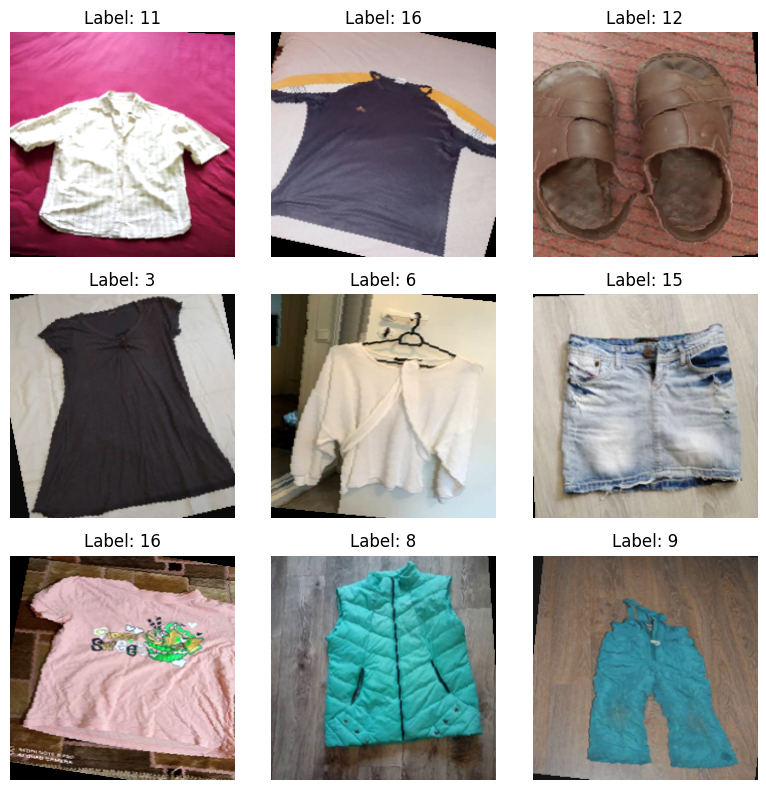

In [18]:
train_loader, test_loader, X_train, X_test, y_train, y_test = get_loader(X, y, augment=True)

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy() # / 255.0 # CHW -> HWC
    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [19]:
# Define input shape and number of classes
input_shape = (224, 224, 3)
num_classes = 19  # 20 but I removed "Not sure"
train_loader, test_loader, X_train, X_test, y_train, y_test = get_loader(X, y, augment=False)


## Try Assignement 1 model

Epoch 1/20: 100%|██████████| 53/53 [06:21<00:00,  7.20s/it]


Train Loss: 2.9802 | Accuracy: 9.02%
Val Loss: 2.7797 | Val Accuracy: 16.99%


Epoch 2/20: 100%|██████████| 53/53 [06:07<00:00,  6.94s/it]


Train Loss: 2.7080 | Accuracy: 17.33%
Val Loss: 3.2846 | Val Accuracy: 9.77%


Epoch 3/20: 100%|██████████| 53/53 [05:46<00:00,  6.54s/it]


...

Train Loss: 0.0112 | Accuracy: 100.00%
Val Loss: 2.5798 | Val Accuracy: 61.42%


Epoch 19/20: 100%|██████████| 53/53 [06:06<00:00,  6.92s/it]


Train Loss: 0.0076 | Accuracy: 100.00%
Val Loss: 2.5680 | Val Accuracy: 61.42%


Epoch 20/20: 100%|██████████| 53/53 [06:06<00:00,  6.91s/it]


Train Loss: 0.0058 | Accuracy: 100.00%
Val Loss: 2.6495 | Val Accuracy: 61.42%
Absolute error: 561
Accuracy: 0.6141678129298487
F1-scores (macro): 0.40629878407164993
F1-scores (weighted): 0.5889912393647742


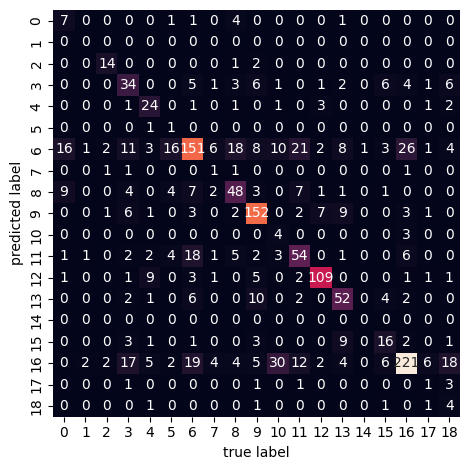

In [62]:
model_ass1 = Assignement1(num_classes)
model_ass1 = train_model(model_ass1, train_loader, val_loader=test_loader, num_epochs=20, device='cpu')
y_, y_pred = get_pred(model_ass1, test_loader)
print_accuracy(y_, y_pred)
torch.save(model_ass1.state_dict(), 'model/small_model_finetuned.pth')

Epoch 1/20: 100%|██████████| 53/53 [06:05<00:00,  6.90s/it]


Train Loss: 3.2576 | Accuracy: 6.10%
Val Loss: 3.2057 | Val Accuracy: 3.65%


Epoch 2/20: 100%|██████████| 53/53 [06:02<00:00,  6.84s/it]


Train Loss: 3.0109 | Accuracy: 8.99%
Val Loss: 3.0691 | Val Accuracy: 11.14%


Epoch 3/20: 100%|██████████| 53/53 [06:00<00:00,  6.80s/it]


...

Train Loss: 0.9528 | Accuracy: 56.43%
Val Loss: 3.1843 | Val Accuracy: 28.95%


Epoch 19/20: 100%|██████████| 53/53 [06:02<00:00,  6.83s/it]


Train Loss: 0.6500 | Accuracy: 66.45%
Val Loss: 5.5369 | Val Accuracy: 15.96%


Epoch 20/20: 100%|██████████| 53/53 [06:01<00:00,  6.82s/it]


Train Loss: 0.9399 | Accuracy: 57.93%
Val Loss: 4.5224 | Val Accuracy: 30.61%
Absolute error: 1009
Accuracy: 0.30605226960110044
F1-scores (macro): 0.22245186452014076
F1-scores (weighted): 0.2996158597419084


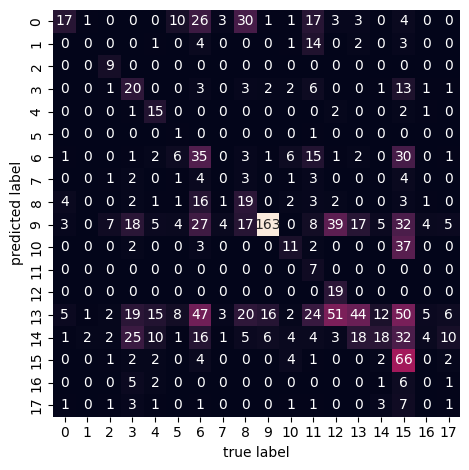

In [ ]:
model_ass1 = Assignement1(num_classes)
model_ass1 = train_model(model_ass1, train_loader, val_loader=test_loader, num_epochs=20, device='cpu')
y_, y_pred = get_pred(model_ass1, test_loader)
print_accuracy(y_, y_pred)  

## Try some VGG
Try VGG16, VGG11, VGG9, VGG11 pretrained

Epoch 1/10: 100%|██████████| 53/53 [09:32<00:00, 10.81s/it]


Train Loss: 3.5569 | Accuracy: 6.31%
Val Loss: 3.7120 | Val Accuracy: 0.48%


Epoch 2/10: 100%|██████████| 53/53 [09:31<00:00, 10.79s/it]


Train Loss: 3.0477 | Accuracy: 5.51%
Val Loss: 3.0049 | Val Accuracy: 1.17%


Epoch 3/10: 100%|██████████| 53/53 [09:00<00:00, 10.21s/it]


...

Train Loss: 2.7849 | Accuracy: 11.62%
Val Loss: 2.7756 | Val Accuracy: 10.87%


Epoch 9/10: 100%|██████████| 53/53 [09:01<00:00, 10.21s/it]


Train Loss: 2.7579 | Accuracy: 11.67%
Val Loss: 2.7450 | Val Accuracy: 13.96%


Epoch 10/10: 100%|██████████| 53/53 [09:01<00:00, 10.22s/it]


Train Loss: 2.7146 | Accuracy: 15.51%
Val Loss: 2.7000 | Val Accuracy: 12.72%
Absolute error: 1269
Accuracy: 0.12723521320495185
F1-scores (macro): 0.07617444514361825
F1-scores (weighted): 0.10922782937520069


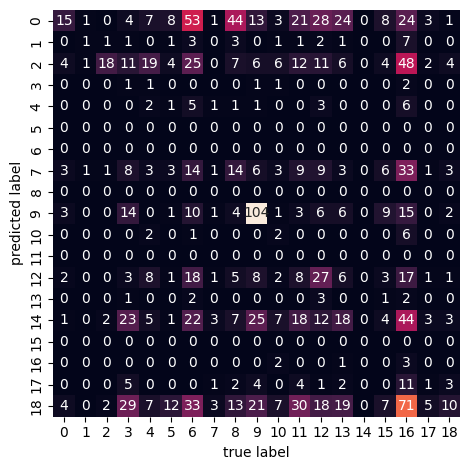

In [48]:
# Initialize the model
model16 = VGG_net(VGG16, 3, num_classes)
model16 = train_model(model16, train_loader, val_loader=test_loader, num_epochs=10, lr=1e-04)
y_, y_pred16 = get_pred(model16, test_loader)
print_accuracy(y_, y_pred16)

Epoch 1/10: 100%|██████████| 53/53 [04:51<00:00,  5.50s/it]


Train Loss: 7.7320 | Accuracy: 5.72%
Val Loss: 707.6831 | Val Accuracy: 0.76%


Epoch 2/10: 100%|██████████| 53/53 [04:51<00:00,  5.50s/it]


Train Loss: 3.5989 | Accuracy: 5.54%
Val Loss: 40.1230 | Val Accuracy: 1.03%


Epoch 3/10: 100%|██████████| 53/53 [04:51<00:00,  5.51s/it]


...

Train Loss: 2.9494 | Accuracy: 1.59%
Val Loss: 279.5666 | Val Accuracy: 6.26%


Epoch 9/10: 100%|██████████| 53/53 [04:51<00:00,  5.49s/it]


Train Loss: 2.9701 | Accuracy: 1.62%
Val Loss: 766.1633 | Val Accuracy: 7.63%


Epoch 10/10: 100%|██████████| 53/53 [04:51<00:00,  5.50s/it]


Train Loss: 2.9528 | Accuracy: 1.56%
Val Loss: 77.7439 | Val Accuracy: 15.96%
Absolute error: 1222
Accuracy: 0.15955983493810177
F1-scores (macro): 0.028706606027569036
F1-scores (weighted): 0.07550747307133554


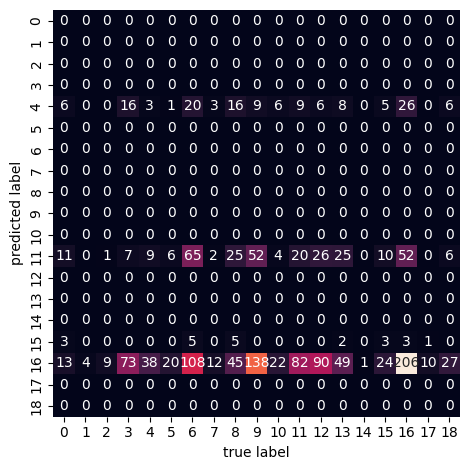

In [64]:
model11 = VGG_net(VGG11, 3, num_classes)
model11 = train_model(model11, train_loader, val_loader=test_loader, num_epochs=10)
y_, y_pred11 = get_pred(model11, test_loader)
print_accuracy(y_, y_pred11)

Epoch 1/10: 100%|██████████| 53/53 [03:34<00:00,  4.04s/it]


Train Loss: 10.7141 | Accuracy: 5.75%
Val Loss: 2.9203 | Val Accuracy: 4.88%


Epoch 2/10: 100%|██████████| 53/53 [03:31<00:00,  3.99s/it]


Train Loss: 3.0588 | Accuracy: 2.92%
Val Loss: 2.9623 | Val Accuracy: 6.12%


Epoch 3/10: 100%|██████████| 53/53 [03:35<00:00,  4.06s/it]


...

Train Loss: 2.9542 | Accuracy: 3.71%
Val Loss: 2.9498 | Val Accuracy: 0.48%


Epoch 9/10: 100%|██████████| 53/53 [03:31<00:00,  3.99s/it]


Train Loss: 2.9691 | Accuracy: 2.27%
Val Loss: 2.9490 | Val Accuracy: 0.89%


Epoch 10/10: 100%|██████████| 53/53 [03:32<00:00,  4.00s/it]


Train Loss: 2.9732 | Accuracy: 3.21%
Val Loss: 2.9444 | Val Accuracy: 0.89%
Absolute error: 1441
Accuracy: 0.008940852819807428
F1-scores (macro): 0.002677816373940349
F1-scores (weighted): 0.00022451157691479203


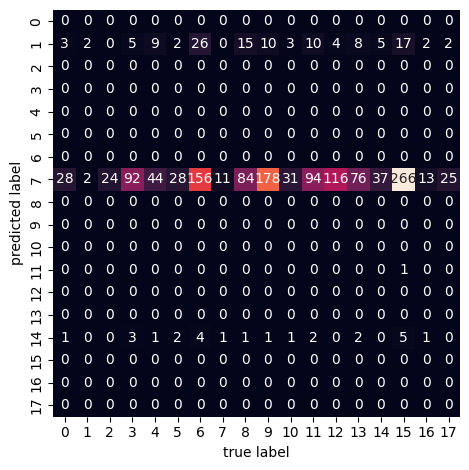

In [42]:
model9 = VGG_net(VGG9, 3, num_classes)
model9 = train_model(model9, train_loader, val_loader=test_loader, num_epochs=10)
y_, y_pred9 = get_pred(model9, test_loader)
print_accuracy(y_, y_pred9)

c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 53/53 [03:03<00:00,  3.47s/it]


Train Loss: 2.9678 | Accuracy: 21.64%
Val Loss: 72.9392 | Val Accuracy: 22.56%


Epoch 2/10: 100%|██████████| 53/53 [03:03<00:00,  3.46s/it]


Train Loss: 2.3491 | Accuracy: 38.97%
Val Loss: 97.4209 | Val Accuracy: 37.55%


Epoch 3/10: 100%|██████████| 53/53 [03:03<00:00,  3.46s/it]


...

Train Loss: 2.4457 | Accuracy: 53.60%
Val Loss: 436.6567 | Val Accuracy: 39.68%


Epoch 9/10: 100%|██████████| 53/53 [03:03<00:00,  3.46s/it]


Train Loss: 2.5890 | Accuracy: 53.42%
Val Loss: 571.3132 | Val Accuracy: 40.30%


Epoch 10/10: 100%|██████████| 53/53 [03:03<00:00,  3.46s/it]


Train Loss: 2.8530 | Accuracy: 51.80%
Val Loss: 539.5364 | Val Accuracy: 36.59%
Absolute error: 922
Accuracy: 0.3658872077028886
F1-scores (macro): 0.1619086945338196
F1-scores (weighted): 0.33514358020024887


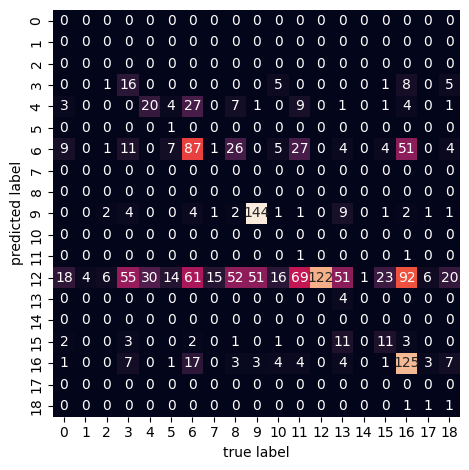

In [66]:
from torchvision import models

model_pre = models.vgg16(pretrained=True)

# Freeze weigth
for param in model_pre.features.parameters():
    param.requires_grad = False

# Change output layer
model_pre.classifier[6] = nn.Linear(4096, num_classes)
model_pre = train_model(model_pre, train_loader, val_loader=test_loader, num_epochs=10)

y_, y_pred_pre = get_pred(model_pre, test_loader)
print_accuracy(y_, y_pred_pre)

c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 53/53 [01:49<00:00,  2.06s/it]


Train Loss: 6.1751 | Accuracy: 5.31%
Val Loss: 2.9350 | Val Accuracy: 1.44%


Epoch 2/10: 100%|██████████| 53/53 [01:49<00:00,  2.06s/it]


Train Loss: 3.0069 | Accuracy: 2.92%
Val Loss: 2.9197 | Val Accuracy: 3.23%


Epoch 3/10: 100%|██████████| 53/53 [01:48<00:00,  2.05s/it]


...

Train Loss: 2.9960 | Accuracy: 3.21%
Val Loss: 2.9340 | Val Accuracy: 2.20%


Epoch 9/10: 100%|██████████| 53/53 [01:50<00:00,  2.08s/it]


Train Loss: 3.0852 | Accuracy: 2.36%
Val Loss: 2.9328 | Val Accuracy: 3.71%


Epoch 10/10: 100%|██████████| 53/53 [01:49<00:00,  2.06s/it]


Train Loss: 3.0112 | Accuracy: 2.03%
Val Loss: 2.8954 | Val Accuracy: 1.93%
Absolute error: 1426
Accuracy: 0.01925722145804677
F1-scores (macro): 0.025959298463891237
F1-scores (weighted): 0.01687536859215216


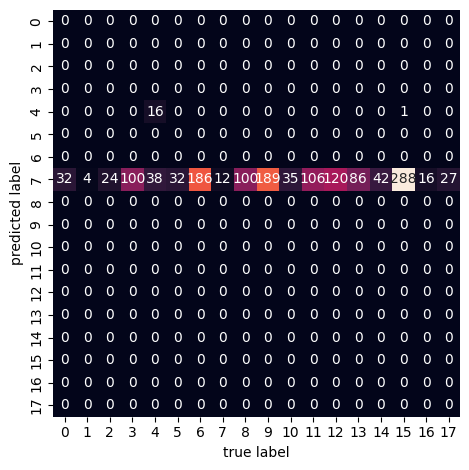

In [43]:
from torchvision import models

model_pre_unfreeze = models.vgg11(pretrained=True)

# Freeze weigth
for param in model_pre_unfreeze.features.parameters():
    param.requires_grad = False

# Change output layer
model_pre_unfreeze.classifier[6] = nn.Linear(4096, num_classes)
model_pre_unfreeze = train_model(model_pre_unfreeze, train_loader, val_loader=test_loader, num_epochs=10)
y_, y_pred_pre_unfreeze = get_pred(model_pre_unfreeze, test_loader)
print_accuracy(y_, y_pred_pre_unfreeze)

c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 53/53 [02:01<00:00,  2.30s/it]


Train Loss: 3.8494 | Accuracy: 17.81%
Val Loss: 2.6834 | Val Accuracy: 27.85%


Epoch 2/10: 100%|██████████| 53/53 [02:01<00:00,  2.29s/it]


Train Loss: 2.5387 | Accuracy: 30.54%
Val Loss: 2.4209 | Val Accuracy: 28.06%


Epoch 3/10: 100%|██████████| 53/53 [02:01<00:00,  2.30s/it]


...

Train Loss: 0.6027 | Accuracy: 76.12%
Val Loss: 2.6768 | Val Accuracy: 55.30%


Epoch 9/10: 100%|██████████| 53/53 [02:02<00:00,  2.31s/it]


Train Loss: 0.5067 | Accuracy: 79.83%
Val Loss: 2.6625 | Val Accuracy: 49.79%


Epoch 10/10: 100%|██████████| 53/53 [02:01<00:00,  2.30s/it]


Train Loss: 0.6789 | Accuracy: 75.32%
Val Loss: 2.9147 | Val Accuracy: 48.49%
Absolute error: 749
Accuracy: 0.48486932599724897
F1-scores (macro): 0.3593249246791128
F1-scores (weighted): 0.5152459770414674


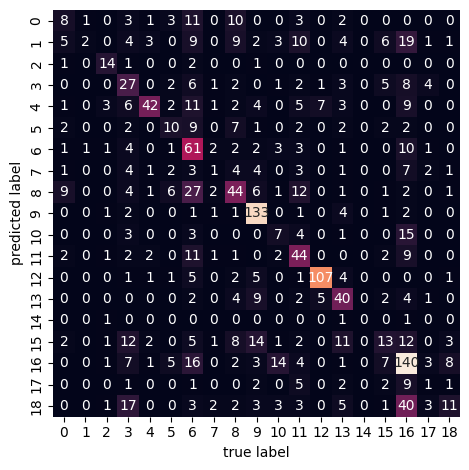

In [ ]:
from torchvision import models

model_pre_unfreeze = models.vgg11(pretrained=True)

# Freeze weigth
for param in model_pre_unfreeze.features.parameters():
    param.requires_grad = False

for i in [16, 18]:
    for param in model_pre_unfreeze.features[i].parameters():
        param.requires_grad = True

# # Change output layer
model_pre_unfreeze.classifier[6] = nn.Linear(4096, num_classes)
model_pre_unfreeze = train_model(model_pre_unfreeze, train_loader, val_loader=test_loader, num_epochs=10, lr=1e-4)
y_, y_pred_pre_unfreeze = get_pred(model_pre_unfreeze, test_loader)
print_accuracy(y_, y_pred_pre_unfreeze)

Epoch 1/10: 100%|██████████| 53/53 [12:44<00:00, 14.43s/it]


Train Loss: 3.4324 | Accuracy: 6.60%
Val Loss: 4.5471 | Val Accuracy: 0.62%


Epoch 2/10: 100%|██████████| 53/53 [11:41<00:00, 13.24s/it]


Train Loss: 3.1197 | Accuracy: 3.92%
Val Loss: 3.0439 | Val Accuracy: 0.00%


Epoch 3/10: 100%|██████████| 53/53 [11:24<00:00, 12.92s/it]


...

Train Loss: 2.8916 | Accuracy: 6.69%
Val Loss: 2.9535 | Val Accuracy: 4.95%


Epoch 9/10: 100%|██████████| 53/53 [11:41<00:00, 13.23s/it]


Train Loss: 2.8570 | Accuracy: 7.52%
Val Loss: 2.8817 | Val Accuracy: 5.91%


Epoch 10/10: 100%|██████████| 53/53 [11:17<00:00, 12.77s/it]


Train Loss: 2.8042 | Accuracy: 8.31%
Val Loss: 2.8296 | Val Accuracy: 9.63%
Absolute error: 1314
Accuracy: 0.09628610729023383
F1-scores (macro): 0.06948316119347242
F1-scores (weighted): 0.09064645876970344


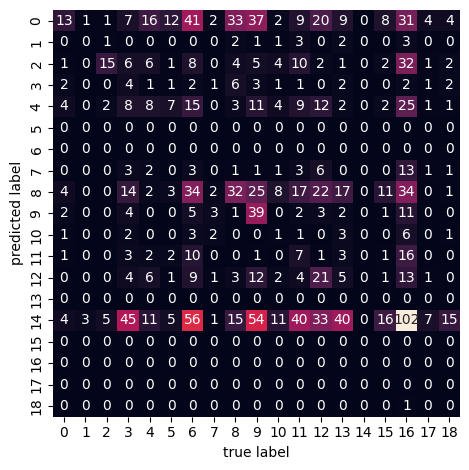

In [53]:
model = VGG_net(VGG19, 3, num_classes)
model = train_model(model, train_loader, val_loader=test_loader, num_epochs=10, lr=1e-04)
y_, y_pred = get_pred(model, test_loader)
print_accuracy(y_, y_pred)

c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 53/53 [03:58<00:00,  4.50s/it]


Train Loss: 3.1612 | Accuracy: 16.01%
Val Loss: 2.5934 | Val Accuracy: 27.51%


Epoch 2/10: 100%|██████████| 53/53 [03:53<00:00,  4.40s/it]


Train Loss: 2.4857 | Accuracy: 31.93%
Val Loss: 2.1507 | Val Accuracy: 27.65%


Epoch 3/10: 100%|██████████| 53/53 [03:53<00:00,  4.41s/it]


...

Train Loss: 0.3014 | Accuracy: 87.09%
Val Loss: 1.9253 | Val Accuracy: 68.91%


Epoch 9/10: 100%|██████████| 53/53 [03:54<00:00,  4.42s/it]


Train Loss: 0.1552 | Accuracy: 92.42%
Val Loss: 1.9206 | Val Accuracy: 67.19%


Epoch 10/10: 100%|██████████| 53/53 [03:53<00:00,  4.40s/it]


Train Loss: 0.1305 | Accuracy: 94.22%
Val Loss: 2.0798 | Val Accuracy: 67.61%
Absolute error: 471
Accuracy: 0.6760660247592847
F1-scores (macro): 0.5381500701442686
F1-scores (weighted): 0.6927596656660299


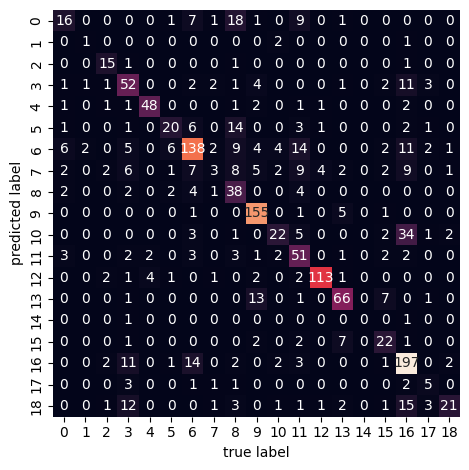

In [54]:
from torchvision import models

model_pre_unfreeze = models.vgg19(pretrained=True)

# Freeze weigth
for param in model_pre_unfreeze.features.parameters():
    param.requires_grad = False

for i in [34, 32, 30, 28]:
    for param in model_pre_unfreeze.features[i].parameters():
        param.requires_grad = True

# # # Change output layer
model_pre_unfreeze.classifier[6] = nn.Linear(4096, num_classes)
model_pre_unfreeze = train_model(model_pre_unfreeze, train_loader, val_loader=test_loader, num_epochs=10, lr=1e-4)
y_, y_pred_pre_unfreeze = get_pred(model_pre_unfreeze, test_loader)
print_accuracy(y_, y_pred_pre_unfreeze)

In [ ]:
torch.save(model_pre_unfreeze.state_dict(), 'model/vgg19_finetuned.pth')

## Test ResNet

Epoch 1/10: 100%|██████████| 53/53 [18:24<00:00, 20.85s/it]


Train Loss: 3.8180 | Accuracy: 3.95%
Val Loss: 86.9777 | Val Accuracy: 6.46%


Epoch 2/10: 100%|██████████| 53/53 [19:41<00:00, 22.28s/it]


Train Loss: 3.5446 | Accuracy: 5.98%
Val Loss: 48.2133 | Val Accuracy: 0.48%


Epoch 3/10: 100%|██████████| 53/53 [19:25<00:00, 21.99s/it]


...

Train Loss: 2.8407 | Accuracy: 9.14%
Val Loss: 3.4685 | Val Accuracy: 5.98%


Epoch 9/10: 100%|██████████| 53/53 [17:57<00:00, 20.34s/it]


Train Loss: 2.8511 | Accuracy: 7.40%
Val Loss: 5.2623 | Val Accuracy: 5.16%


Epoch 10/10: 100%|██████████| 53/53 [17:59<00:00, 20.37s/it]


Train Loss: 2.8270 | Accuracy: 9.43%
Val Loss: 3.1526 | Val Accuracy: 7.02%
Absolute error: 1352
Accuracy: 0.07015130674002751
F1-scores (macro): 0.04843299312541076
F1-scores (weighted): 0.05249612116877355


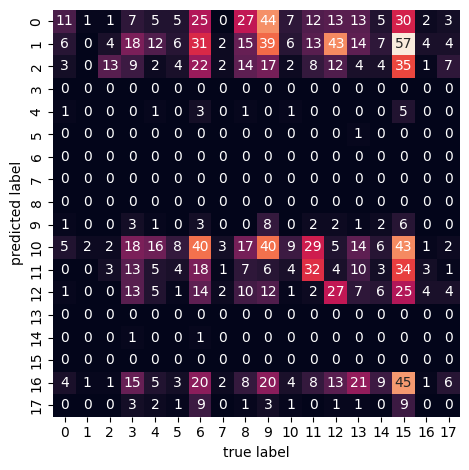

In [37]:
model_resnet50 = ResNet50(img_channels=3, num_classes=num_classes)
model_resnet50 = train_model(model_resnet50, train_loader, val_loader=test_loader, num_epochs=10)
y_, y_pred_resnet50= get_pred(model_resnet50, test_loader)
print_accuracy(y_, y_pred_resnet50)

## Try decision tree

Absolute error: 1085
Accuracy: 0.25378266850068776
F1-scores (macro): 0.14450001217465203
F1-scores (weighted): 0.25388336348599605


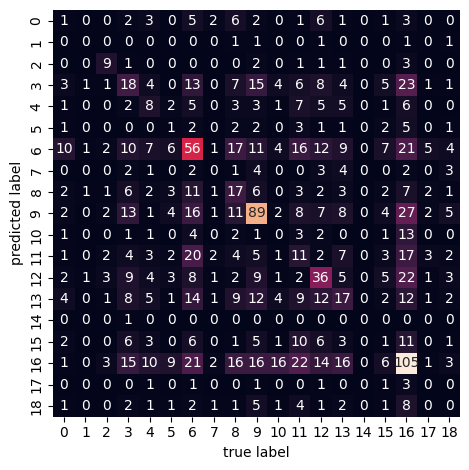

In [41]:
X_train_array = np.array(X_train.tolist())
X_test_array = np.array(X_test.tolist())

X_train_flat = X_train_array.reshape(X_train_array.shape[0], -1)
X_test_flat = X_test_array.reshape(X_test_array.shape[0], -1)

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()
clf.fit(X_train_flat, y_train)

y_pred = clf.predict(X_test_flat)

print_accuracy(y_test, y_pred)

## 3 fold validation

In [48]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from tqdm import tqdm


def get_loader_from_indices(X, y, train_idx, val_idx, augment=False, batch_size=64):
    """
    Build train and validation loaders given index splits.
    """
    X_arr = np.stack(X.values)
    y_arr = y.values

    # Create tensors for full dataset
    X_tensor = torch.tensor(X_arr, dtype=torch.float32)
    y_tensor = torch.tensor(y_arr, dtype=torch.long)

    # Subset datasets
    train_dataset = AugmentedImageDataset(X_tensor, y_tensor, augment=augment)
    val_dataset = AugmentedImageDataset(X_tensor, y_tensor, augment=False)

    # Use Subset to pick indices
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_dataset, val_idx)

    # DataLoaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


from sklearn.metrics import f1_score, confusion_matrix

def train_model_bis(model, train_loader, val_loader=None, num_epochs=10, lr=1e-3,
                    weights=None, device='cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    final_f1 = None
    final_conf_matrix = None

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100.0 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%")

        # Validation
        if val_loader is not None:
            model.eval()
            running_loss, correct, total = 0.0, 0, 0
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    running_loss += loss.item() * images.size(0)
                    _, preds = outputs.max(1)
                    correct += preds.eq(labels).sum().item()
                    total += labels.size(0)

                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            val_loss = running_loss / total
            val_acc = 100.0 * correct / total
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            print(f"           Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

            # If this is the last epoch, compute F1 and confusion matrix
            if epoch == num_epochs - 1:
                print_accuracy(np.array(all_labels), np.array(all_preds))

    return model, history



def cross_validate(model_class, X, y, weights=None, k=3,
                   num_epochs=10, lr=1e-3, device='cpu'):    
    """
    Perform k-fold cross-validation.
    model_class: a callable that returns a fresh model instance when called.
    X: pandas Series of image arrays (channels-first already applied).
    y: pandas Series of integer labels.
    Returns list of histories and list of fold metrics.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_metrics = []
    all_histories = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"\n--- Fold {fold}/{k} ---")
        train_loader, val_loader = get_loader_from_indices(
            X, y, train_idx, val_idx, augment=True, batch_size=64
        )

        model = model_class()
        trained_model, history = train_model_bis(
            model, train_loader, val_loader,
            num_epochs=num_epochs, lr=lr,
            weights=weights, device=device
        )
        model_save_path = f"model_fold_{fold}.pth"
        torch.save(trained_model.state_dict(), model_save_path)

        all_histories.append(history)
        final_val_acc = history['val_acc'][-1]
        final_val_loss = history['val_loss'][-1]
        fold_metrics.append({
            'fold': fold,
            'val_loss': final_val_loss,
            'val_acc': final_val_acc,
            })

    return all_histories, fold_metrics


In [52]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cv_accuracy(all_histories):
    """
    all_histories: list of dicts, each dict has keys
      'train_acc' and 'val_acc' (lists of length num_epochs).
    """
    # Stack into arrays of shape (n_folds, n_epochs)
    train_acc = np.array([h['train_acc'] for h in all_histories])
    val_acc   = np.array([h['val_acc']   for h in all_histories])

    # Compute mean across folds
    mean_train = train_acc.mean(axis=0)
    mean_val   = val_acc.mean(axis=0)

    epochs = np.arange(1, mean_train.shape[0] + 1)

    plt.figure()
    plt.plot(epochs, mean_train, label='Train Accuracy')
    plt.plot(epochs, mean_val,   label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('3-Fold CV: Accuracy Over Epochs')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Usage (after cross_validate):
# plot_cv_accuracy(all_histories)



--- Fold 1/3 ---


Epoch 1/6: 100%|██████████| 27/27 [03:04<00:00,  6.84s/it]


Epoch 1: Train Loss=1.9635, Train Acc=16.71%
           Val Loss=1.9586, Val Acc=39.81%


Epoch 2/6: 100%|██████████| 27/27 [03:04<00:00,  6.82s/it]


Epoch 2: Train Loss=1.7406, Train Acc=24.64%
           Val Loss=2.1832, Val Acc=7.15%


...

Epoch 4: Train Loss=1.5851, Train Acc=31.92%
           Val Loss=1.6356, Val Acc=33.37%


Epoch 5/6: 100%|██████████| 27/27 [03:03<00:00,  6.78s/it]


Epoch 5: Train Loss=1.4751, Train Acc=32.10%
           Val Loss=1.6545, Val Acc=27.18%


Epoch 6/6: 100%|██████████| 27/27 [03:02<00:00,  6.77s/it]


Epoch 6: Train Loss=1.4622, Train Acc=34.13%
           Val Loss=1.6318, Val Acc=21.57%
Absolute error: 658
Accuracy: 0.21573301549463647
F1-scores (macro): 0.23699577539453673
F1-scores (weighted): 0.2322372585855464


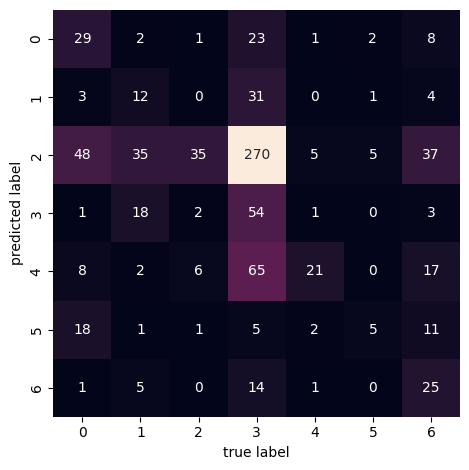


--- Fold 2/3 ---


Epoch 1/6: 100%|██████████| 27/27 [03:04<00:00,  6.82s/it]


Epoch 1: Train Loss=1.9095, Train Acc=18.31%
           Val Loss=2.2391, Val Acc=12.05%


Epoch 2/6: 100%|██████████| 27/27 [03:03<00:00,  6.80s/it]


Epoch 2: Train Loss=1.6778, Train Acc=25.40%
           Val Loss=1.7874, Val Acc=39.38%


...

Epoch 4: Train Loss=1.5649, Train Acc=27.19%
           Val Loss=1.4836, Val Acc=41.65%


Epoch 5/6: 100%|██████████| 27/27 [03:04<00:00,  6.82s/it]


Epoch 5: Train Loss=1.4191, Train Acc=35.30%
           Val Loss=1.5024, Val Acc=34.84%


Epoch 6/6: 100%|██████████| 27/27 [03:03<00:00,  6.80s/it]


Epoch 6: Train Loss=1.3165, Train Acc=33.51%
           Val Loss=1.6695, Val Acc=28.40%
Absolute error: 600
Accuracy: 0.2840095465393795
F1-scores (macro): 0.26791090661895434
F1-scores (weighted): 0.32397160402894754


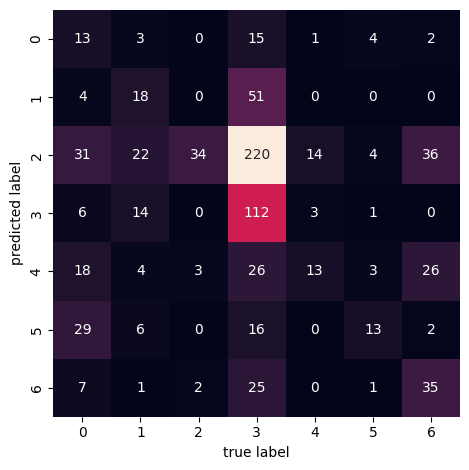


--- Fold 3/3 ---


Epoch 1/6: 100%|██████████| 27/27 [03:03<00:00,  6.80s/it]


Epoch 1: Train Loss=1.9346, Train Acc=16.82%
           Val Loss=2.0080, Val Acc=13.01%


Epoch 2/6: 100%|██████████| 27/27 [03:02<00:00,  6.77s/it]


Epoch 2: Train Loss=1.6933, Train Acc=21.71%
           Val Loss=1.8205, Val Acc=16.59%


...

Epoch 4: Train Loss=1.5838, Train Acc=30.53%
           Val Loss=1.8123, Val Acc=18.26%


Epoch 5/6: 100%|██████████| 27/27 [03:03<00:00,  6.79s/it]


Epoch 5: Train Loss=1.5313, Train Acc=30.17%
           Val Loss=1.5168, Val Acc=27.33%


Epoch 6/6: 100%|██████████| 27/27 [03:03<00:00,  6.80s/it]


Epoch 6: Train Loss=1.4169, Train Acc=32.56%
           Val Loss=1.5640, Val Acc=37.83%
Absolute error: 521
Accuracy: 0.37828162291169454
F1-scores (macro): 0.32439774811146654
F1-scores (weighted): 0.3886128906462967


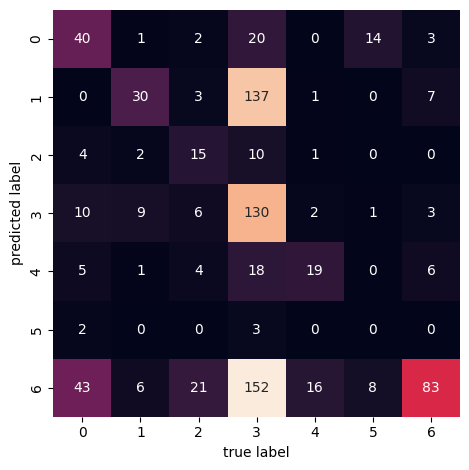

[{'fold': 1, 'val_loss': 1.63176309792447, 'val_acc': 21.573301549463647}, {'fold': 2, 'val_loss': 1.6695132978207172, 'val_acc': 28.400954653937948}, {'fold': 3, 'val_loss': 1.563956727560494, 'val_acc': 37.82816229116945}]


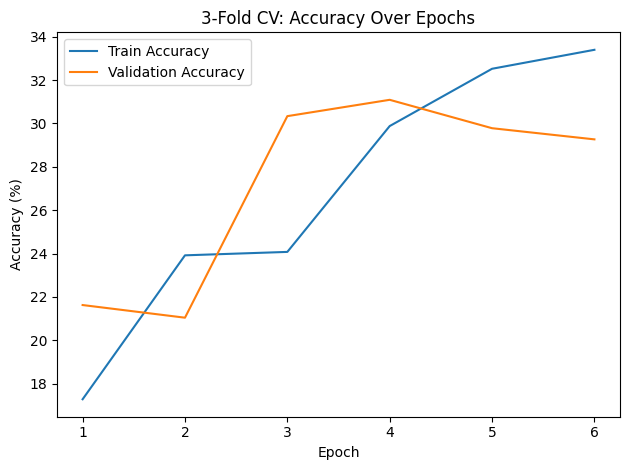

In [53]:
from sklearn.utils import compute_class_weight
weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(y), y=y), dtype=torch.float32)
histories, metrics = cross_validate(lambda: Assignement1(num_classes), X, y, weights=weights,
                                   k=3, num_epochs=6, lr=1e-3, device='cpu')
print(metrics)
plot_cv_accuracy(histories)

In [21]:
from torchvision import models

def create_vgg_19():

    model_pre_unfreeze = models.vgg19(pretrained=True)

    # Freeze weigth
    for param in model_pre_unfreeze.features.parameters():
        param.requires_grad = False

    for i in [34, 32, 30, 28]:
        for param in model_pre_unfreeze.features[i].parameters():
            param.requires_grad = True

    # Change output layer
    model_pre_unfreeze.classifier[6] = nn.Linear(4096, num_classes)
    return model_pre_unfreeze

histories, metrics = cross_validate(lambda: create_vgg_19(), X, y, weights=weights,
                                   k=3, num_epochs=10, lr=1e-4, device='cpu')
print(metrics)


--- Fold 1/3 ---


c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 51/51 [03:23<00:00,  4.00s/it]


Epoch 1: Train Loss=2.4331, Train Acc=35.91%
           Val Loss=1.5581, Val Acc=56.25%


Epoch 2/10: 100%|██████████| 51/51 [03:24<00:00,  4.00s/it]


Epoch 2: Train Loss=1.6786, Train Acc=58.05%
           Val Loss=1.1691, Val Acc=66.03%


...

Epoch 8: Train Loss=0.2773, Train Acc=87.16%
           Val Loss=2.2545, Val Acc=78.08%


Epoch 9/10: 100%|██████████| 51/51 [03:46<00:00,  4.43s/it]


Epoch 9: Train Loss=0.2463, Train Acc=89.82%
           Val Loss=2.8180, Val Acc=80.74%


Epoch 10/10: 100%|██████████| 51/51 [03:45<00:00,  4.42s/it]


Epoch 10: Train Loss=0.2272, Train Acc=89.76%
           Val Loss=2.1970, Val Acc=79.57%
[{'fold': 1, 'val_loss': 1.5639857714719112, 'val_acc': 82.67326732673267}, {'fold': 2, 'val_loss': 1.6619377031968474, 'val_acc': 78.69969040247678}, {'fold': 3, 'val_loss': 2.1969905251689004, 'val_acc': 79.56656346749226}]


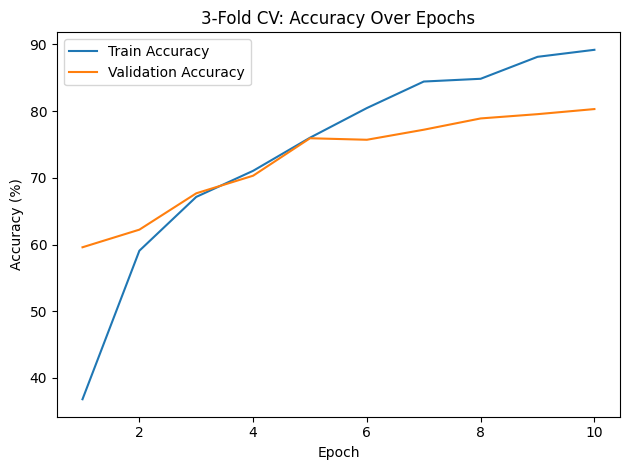

In [22]:
plot_cv_accuracy(histories)


--- Fold 1/3 ---


c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 51/51 [03:09<00:00,  3.71s/it]


Epoch 1: Train Loss=2.4966, Train Acc=36.13%
           Val Loss=1.6506, Val Acc=49.88%


Epoch 2/10: 100%|██████████| 51/51 [03:08<00:00,  3.70s/it]


Epoch 2: Train Loss=1.6594, Train Acc=55.76%
           Val Loss=1.2531, Val Acc=61.45%


...

Epoch 8: Train Loss=0.3466, Train Acc=86.91%
           Val Loss=2.2924, Val Acc=76.66%


Epoch 9/10: 100%|██████████| 51/51 [03:10<00:00,  3.74s/it]


Epoch 9: Train Loss=0.2195, Train Acc=90.25%
           Val Loss=2.5872, Val Acc=78.20%


Epoch 10/10: 100%|██████████| 51/51 [03:10<00:00,  3.73s/it]


Epoch 10: Train Loss=0.2113, Train Acc=90.56%
           Val Loss=2.7936, Val Acc=79.88%
[{'fold': 1, 'val_loss': 1.267142369015382, 'val_acc': 77.5990099009901}, {'fold': 2, 'val_loss': 1.906727027671625, 'val_acc': 79.07120743034056}, {'fold': 3, 'val_loss': 2.793614114567222, 'val_acc': 79.87616099071208}]


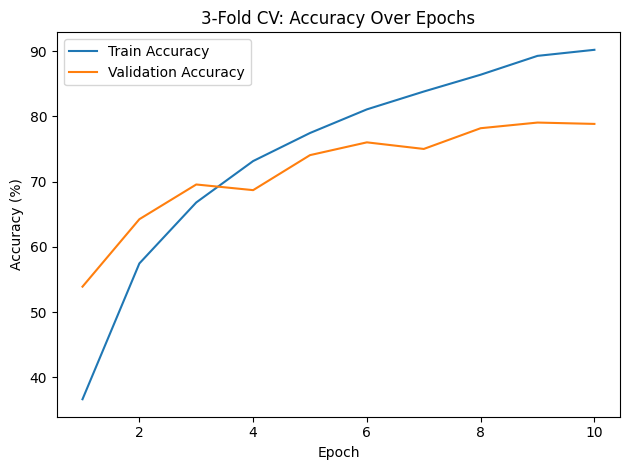

In [23]:
from torchvision import models

def create_vgg_16():

    model_pre_unfreeze = models.vgg16(pretrained=True)

    # Freeze weigth
    for param in model_pre_unfreeze.features.parameters():
        param.requires_grad = False

    for i in [24, 26, 28]:
        for param in model_pre_unfreeze.features[i].parameters():
            param.requires_grad = True

    # Change output layer
    model_pre_unfreeze.classifier[6] = nn.Linear(4096, num_classes)
    return model_pre_unfreeze

histories, metrics = cross_validate(lambda: create_vgg_16(), X, y, weights=weights,
                                   k=3, num_epochs=10, lr=1e-4, device='cpu')
print(metrics)
plot_cv_accuracy(histories)

# Slow Fashion dataset

In [55]:
import pandas as pd

df = pd.read_pickle("data/slowfashion.pkl")
df['label'] = label_encoder.fit_transform(df['main'])
X = df['image'].apply(lambda img: np.transpose(img, (2, 0, 1)))
y = df['label']
num_classes = df["label"].nunique()
print(num_classes)

label_counts = df['label'].value_counts()
total_samples = len(df)
class_weights = total_samples / (len(label_counts) * label_counts)
weights = torch.tensor(class_weights.sort_index().values, dtype=torch.float32)

7


In [56]:
def load_vgg19_freeze():
    model = models.vgg19(pretrained=False)

    for param in model.features.parameters(): # freeze all
        param.requires_grad = False

    for i in [34, 32]: # unfreeze the last 2 conv layers to keep some of the fne tuning
        for param in model_pre_unfreeze.features[i].parameters():
            param.requires_grad = True

    model.classifier[6] = nn.Linear(4096, 19) # Change output layer to load the fine tune one

    state_dict = torch.load('model/vgg19_finetuned.pth', map_location='cpu')
    model.load_state_dict(state_dict)

    model.classifier[6] = nn.Linear(4096, num_classes) # New classification layer
    return model



histories, metrics = cross_validate(lambda: load_vgg19_freeze(), X, y, weights=weights,
                                   k=3, num_epochs=10, lr=1e-4, device='cpu')
print(metrics)
plot_cv_accuracy(histories)


--- Fold 1/3 ---


c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


NameError: name 'model_pre_unfreeze' is not defined


--- Fold 1/3 ---


Epoch 1/10: 100%|██████████| 27/27 [01:26<00:00,  3.22s/it]


Epoch 1: Train Loss=1.8865, Train Acc=17.66%
           Val Loss=2.5004, Val Acc=6.32%


Epoch 2/10: 100%|██████████| 27/27 [01:26<00:00,  3.22s/it]


Epoch 2: Train Loss=1.6759, Train Acc=26.85%
           Val Loss=1.8477, Val Acc=20.02%


...

Epoch 8: Train Loss=1.3281, Train Acc=41.47%
           Val Loss=2.5245, Val Acc=13.83%


Epoch 9/10: 100%|██████████| 27/27 [01:19<00:00,  2.95s/it]


Epoch 9: Train Loss=1.3149, Train Acc=45.70%
           Val Loss=2.6413, Val Acc=15.02%


Epoch 10/10: 100%|██████████| 27/27 [01:19<00:00,  2.93s/it]


Epoch 10: Train Loss=1.2554, Train Acc=45.05%
           Val Loss=3.7118, Val Acc=4.65%
Absolute error: 800
Accuracy: 0.04648390941597139
F1-scores (macro): 0.04008343305740547
F1-scores (weighted): 0.00979778070879305


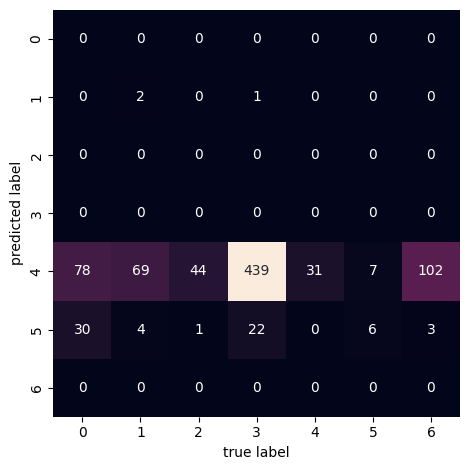


--- Fold 2/3 ---


Epoch 1/10: 100%|██████████| 27/27 [01:20<00:00,  2.99s/it]


Epoch 1: Train Loss=1.8848, Train Acc=18.55%
           Val Loss=2.0826, Val Acc=14.80%


Epoch 2/10: 100%|██████████| 27/27 [01:19<00:00,  2.96s/it]


Epoch 2: Train Loss=1.7159, Train Acc=29.10%
           Val Loss=2.0666, Val Acc=15.39%


...

Epoch 8: Train Loss=1.3157, Train Acc=41.86%
           Val Loss=2.2459, Val Acc=9.43%


Epoch 9/10: 100%|██████████| 27/27 [01:19<00:00,  2.95s/it]


Epoch 9: Train Loss=1.2526, Train Acc=43.89%
           Val Loss=2.3816, Val Acc=10.86%


Epoch 10/10: 100%|██████████| 27/27 [01:19<00:00,  2.96s/it]


Epoch 10: Train Loss=1.2225, Train Acc=42.34%
           Val Loss=1.9414, Val Acc=16.23%
Absolute error: 702
Accuracy: 0.162291169451074
F1-scores (macro): 0.18881258390472558
F1-scores (weighted): 0.10933502909026711


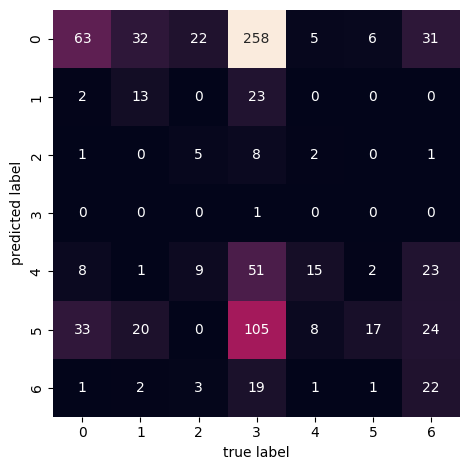


--- Fold 3/3 ---


Epoch 1/10: 100%|██████████| 27/27 [01:20<00:00,  2.98s/it]


Epoch 1: Train Loss=1.9211, Train Acc=20.39%
           Val Loss=2.5299, Val Acc=13.72%


Epoch 2/10: 100%|██████████| 27/27 [01:20<00:00,  2.98s/it]


Epoch 2: Train Loss=1.7181, Train Acc=26.77%
           Val Loss=2.2168, Val Acc=6.09%


...

Epoch 8: Train Loss=1.3472, Train Acc=40.73%
           Val Loss=2.9631, Val Acc=7.64%


Epoch 9/10: 100%|██████████| 27/27 [01:20<00:00,  2.96s/it]


Epoch 9: Train Loss=1.2915, Train Acc=41.56%
           Val Loss=2.6508, Val Acc=34.73%


Epoch 10/10: 100%|██████████| 27/27 [01:20<00:00,  2.98s/it]


Epoch 10: Train Loss=1.2208, Train Acc=42.28%
           Val Loss=1.8540, Val Acc=17.78%
Absolute error: 689
Accuracy: 0.17780429594272076
F1-scores (macro): 0.146198967677844
F1-scores (weighted): 0.18392948210261462


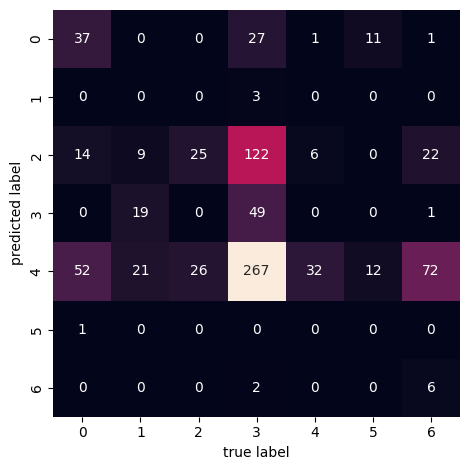

[{'fold': 1, 'val_loss': 3.7118088332347847, 'val_acc': 4.64839094159714}, {'fold': 2, 'val_loss': 1.9414473985430734, 'val_acc': 16.2291169451074}, {'fold': 3, 'val_loss': 1.8539585270574384, 'val_acc': 17.780429594272075}]


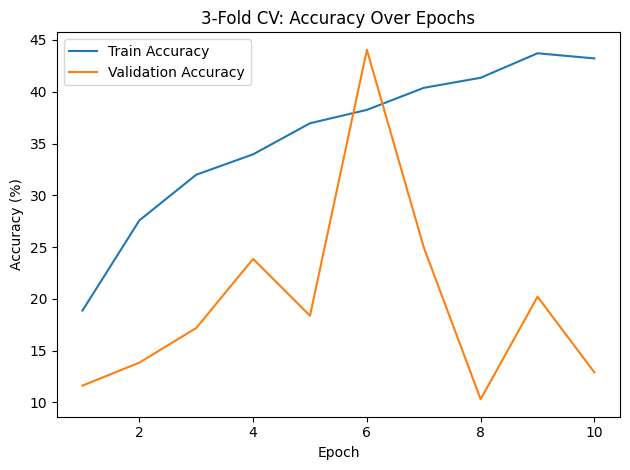

In [ ]:
def load_small_cnn():
    model = Assignement1(num_classes=19)  # original number of classes

    # Step 2: Load saved weights
    model.load_state_dict(torch.load('model/small_model_finetuned.pth', map_location=torch.device('cpu')))  # or 'cuda'

    # Step 3: Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Step 4: Unfreeze only the last conv block
    for param in model.conv_last.parameters():
        param.requires_grad = True
    for param in model.bn_last.parameters():
        param.requires_grad = True

    # Step 5: Replace the classifier to match the new number of classes
    model.fc2 = nn.Linear(1024, num_classes)
    return model

histories, metrics = cross_validate(lambda: load_small_cnn(), X, y, weights=weights,
                                   k=3, num_epochs=10, lr=1e-4, device='cpu')
print(metrics)
plot_cv_accuracy(histories)

In [1]:
def load_small_cnn():
    model = Assignement1(num_classes=19)  # original number of classes

    # Step 2: Load saved weights
    model.load_state_dict(torch.load('model/small_model_finetuned.pth', map_location=torch.device('cpu')))  # or 'cuda'

    # Step 3: Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Step 4: Unfreeze only the last conv block
    for param in model.conv_last.parameters():
        param.requires_grad = True
    for param in model.bn_last.parameters():
        param.requires_grad = True

    # Step 5: Replace the classifier to match the new number of classes
    model.fc2 = nn.Linear(1024, num_classes)
    return model

histories, metrics = cross_validate(lambda: load_small_cnn(), X, y, weights=weights,
                                   k=3, num_epochs=10, lr=1e-4, device='cpu')
print(metrics)
plot_cv_accuracy(histories)

NameError: name 'cross_validate' is not defined